### Preparacion de Datos

In [13]:
import pandas as pd

# 1. Cargar datos
df = pd.read_csv("TelecomX_Clean.csv")

# 2. Eliminar columnas irrelevantes
df = df.drop('customerID', axis=1)

# 3. Forzar numéricos y rellenar nulos
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(df['account.Charges.Total'].median())

# 4. Codificar Variable Objetivo 'Churn' a números
df['Churn'] = df['Churn'].astype(int)

# 5. One-Hot Encoding a variables categóricas
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns
if 'Churn' in categorical_cols:
    categorical_cols = categorical_cols.drop('Churn')

# pd.get_dummies es una función nativa de pandas
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 6. Estandarización MANUAL (Z-Score) usando solo Pandas
numerical_cols = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']
for col in numerical_cols:
    # Restamos el promedio y dividimos por la desviación estándar
    df_encoded[col] = (df_encoded[col] - df_encoded[col].mean()) / df_encoded[col].std()

# 7. Balanceo de Clases MANUAL usando pandas .sample()
df_majority = df_encoded[df_encoded['Churn'] == 0]
df_minority = df_encoded[df_encoded['Churn'] == 1]

# Multiplicar la clase minoritaria (oversampling) para empatar los 5,398
df_minority_upsampled = df_minority.sample(n=len(df_majority), replace=True, random_state=42)

# 8. Unir de nuevo los dataframes
df_prepared = pd.concat([df_majority, df_minority_upsampled])

# Mostrar resultados
print(f"Dimensiones después del Balanceo (Solo Pandas): {df_prepared.shape}")
print(f"Distribución Final:\n{df_prepared['Churn'].value_counts()}")

Dimensiones después del Balanceo (Solo Pandas): (10796, 31)
Distribución Final:
Churn
0    5398
1    5398
Name: count, dtype: int64


### Correlacion y Seleccion de Variables

### 1.1 Analisis de Correclacion

C:\Users\spide\AppData\Local\Temp\ipykernel_20404\2741919580.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='coolwarm')


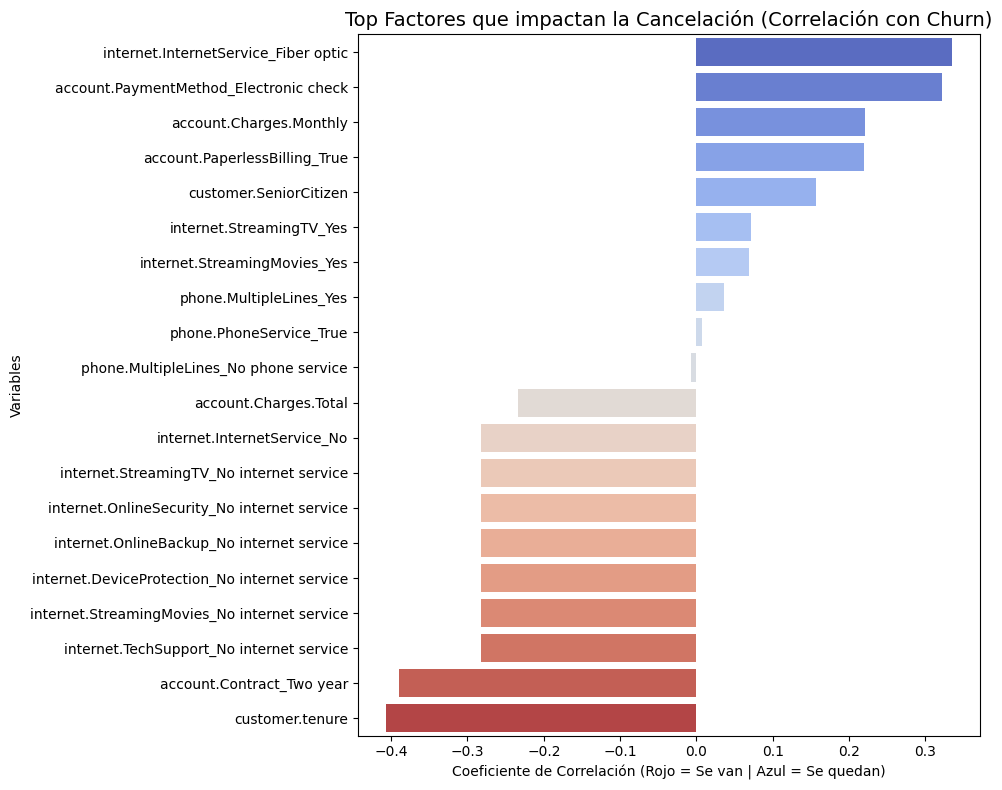

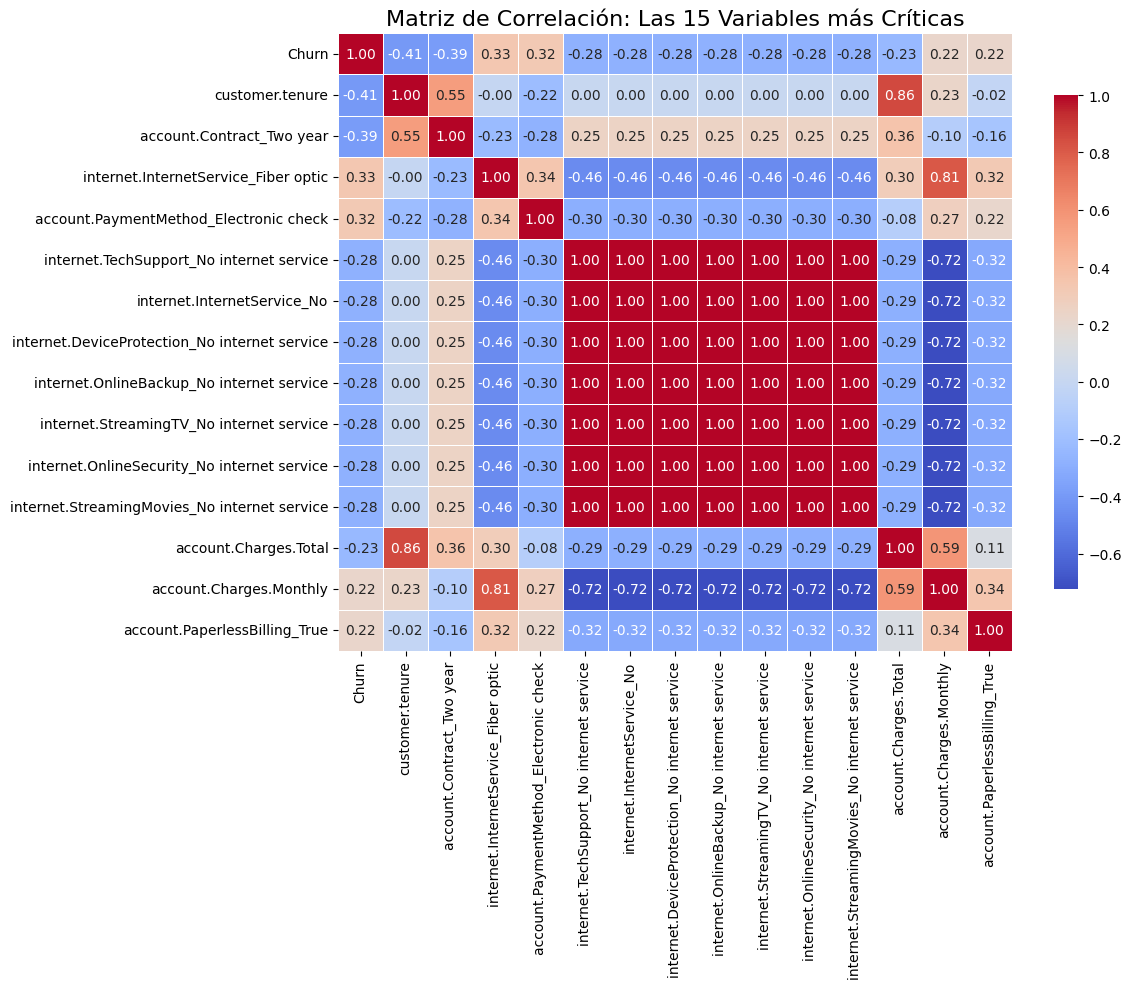

--- VARIABLES CANDIDATAS PRINCIPALES PARA EL MODELO ---
Aumentan el Churn (Positivas):
 internet.InternetService_Fiber optic      0.334446
account.PaymentMethod_Electronic check    0.321344
account.Charges.Monthly                   0.220980
Name: Churn, dtype: float64

Previenen el Churn (Negativas):
 internet.TechSupport_No internet service   -0.282927
account.Contract_Two year                  -0.389437
customer.tenure                            -0.406691
Name: Churn, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular las correlaciones usando la base de datos ya preparada y balanceada
corr_matrix = df_prepared.corr()

# Extraer solo las correlaciones directas contra 'Churn'
churn_corr = corr_matrix['Churn'].sort_values(ascending=False)

# 2. VISUALIZACIÓN 1: Gráfico de Barras de Impacto
# Excluimos 'Churn' vs 'Churn' (que siempre es 1.0)
top_pos = churn_corr.head(11)[1:] 
top_neg = churn_corr.tail(10)
top_features = pd.concat([top_pos, top_neg])

plt.figure(figsize=(10, 8))
sns.barplot(x=top_features.values, y=top_features.index, palette='coolwarm')
plt.title('Top Factores que impactan la Cancelación (Correlación con Churn)', fontsize=14)
plt.xlabel('Coeficiente de Correlación (Rojo = Se van | Azul = Se quedan)')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

# 3. VISUALIZACIÓN 2: Mapa de Calor (Matriz de Correlación) de las Top 15
# Filtramos las 15 columnas que tienen la correlación más fuerte (positiva o negativa)
top_15_cols = churn_corr.abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(12, 10))
sns.heatmap(df_prepared[top_15_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", 
            linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Matriz de Correlación: Las 15 Variables más Críticas', fontsize=16)
plt.tight_layout()
plt.show()

print("--- VARIABLES CANDIDATAS PRINCIPALES PARA EL MODELO ---")
print("Aumentan el Churn (Positivas):\n", top_pos.head(3))
print("\nPrevienen el Churn (Negativas):\n", top_neg.tail(3))

### 1.2 Analisis Dirigido

C:\Users\spide\AppData\Local\Temp\ipykernel_20404\594368112.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='customer.tenure', ax=axes[0, 0], palette=['#4C72B0', '#C44E52'])
C:\Users\spide\AppData\Local\Temp\ipykernel_20404\594368112.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='account.Charges.Total', ax=axes[0, 1], palette=['#4C72B0', '#C44E52'])


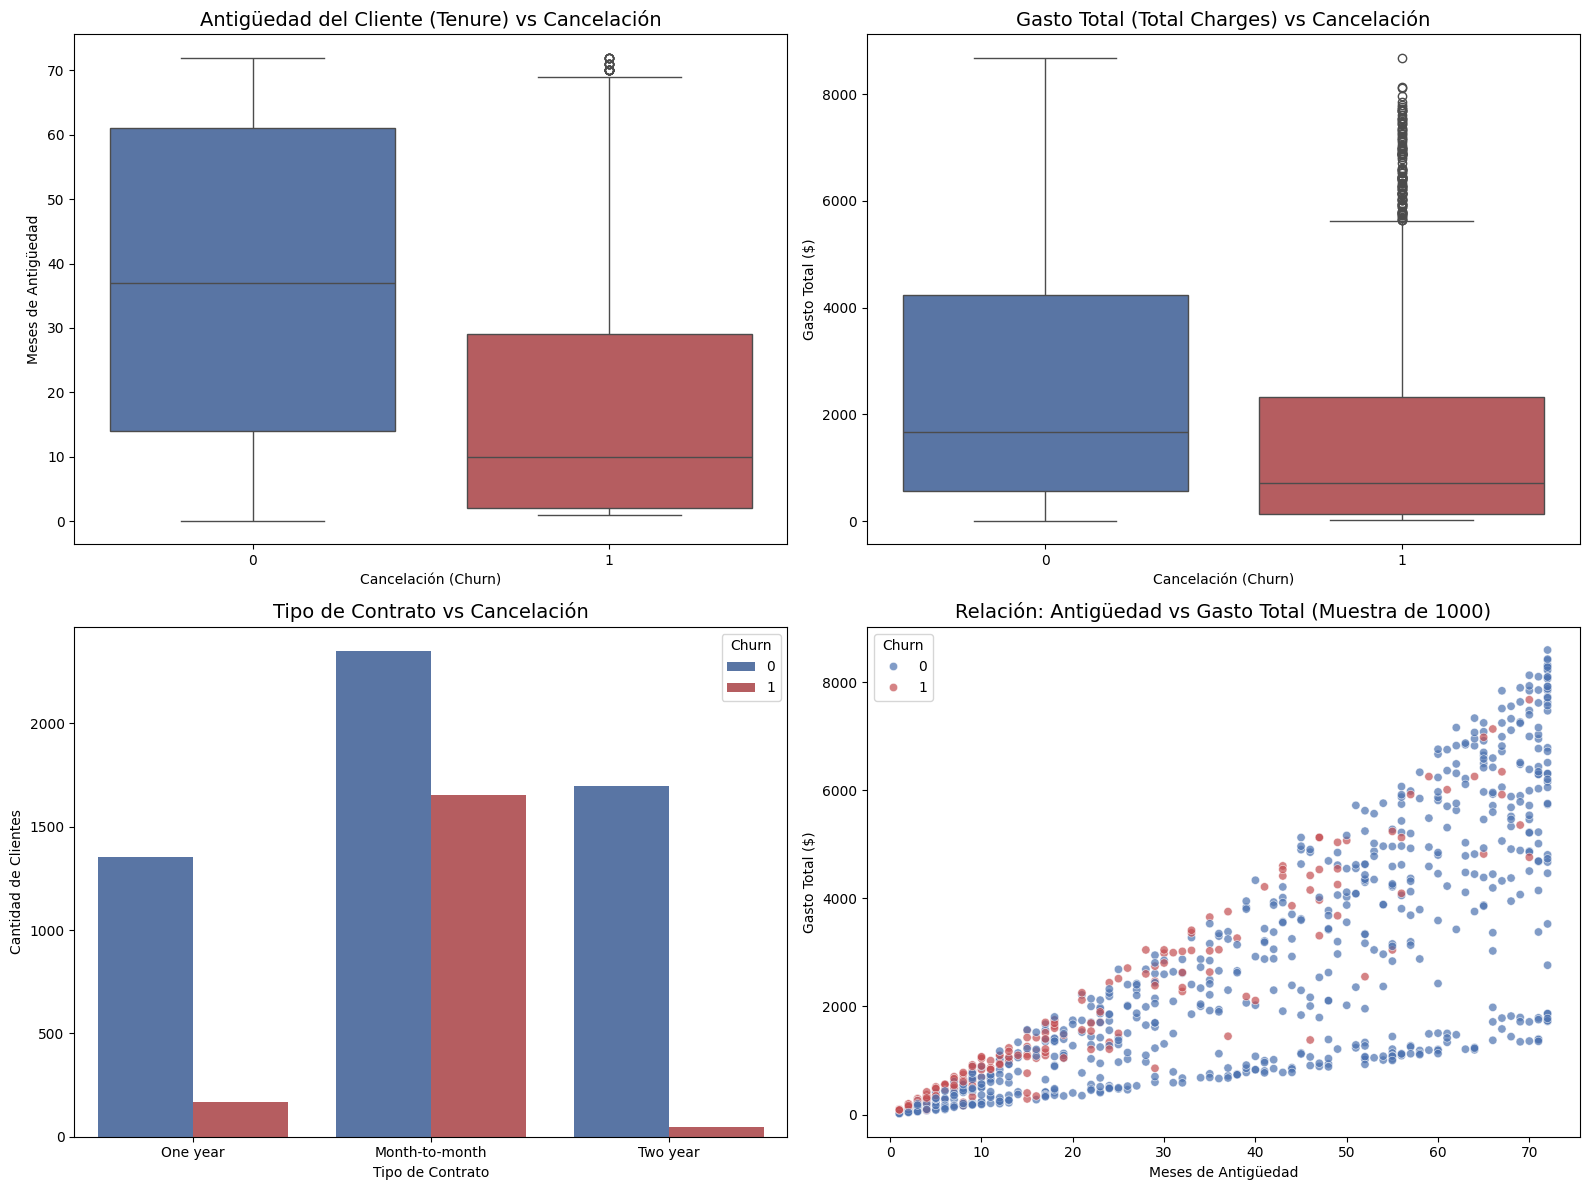

In [17]:

# Asegurar tipo de datos correcto
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(df['account.Charges.Total'].median())
df['Churn'] = df['Churn'].replace({True: 'Si (Canceló)', False: 'No (Se quedó)'})

# Crear la figura y los subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Boxplot: Tiempo de Contrato (Tenure) vs Cancelación
sns.boxplot(data=df, x='Churn', y='customer.tenure', ax=axes[0, 0], palette=['#4C72B0', '#C44E52'])
axes[0, 0].set_title('Antigüedad del Cliente (Tenure) vs Cancelación', fontsize=14)
axes[0, 0].set_xlabel('Cancelación (Churn)')
axes[0, 0].set_ylabel('Meses de Antigüedad')

# 2. Boxplot: Gasto Total vs Cancelación
sns.boxplot(data=df, x='Churn', y='account.Charges.Total', ax=axes[0, 1], palette=['#4C72B0', '#C44E52'])
axes[0, 1].set_title('Gasto Total (Total Charges) vs Cancelación', fontsize=14)
axes[0, 1].set_xlabel('Cancelación (Churn)')
axes[0, 1].set_ylabel('Gasto Total ($)')

# 3. Countplot: Tipo de Contrato vs Cancelación
sns.countplot(data=df, x='account.Contract', hue='Churn', ax=axes[1, 0], palette=['#4C72B0', '#C44E52'])
axes[1, 0].set_title('Tipo de Contrato vs Cancelación', fontsize=14)
axes[1, 0].set_xlabel('Tipo de Contrato')
axes[1, 0].set_ylabel('Cantidad de Clientes')

# 4. Scatterplot: Tiempo vs Gasto Total (Coloreado por Churn)
# Usaremos una muestra para no saturar el gráfico
sns.scatterplot(data=df.sample(1000, random_state=42), x='customer.tenure', y='account.Charges.Total', 
                hue='Churn', alpha=0.7, ax=axes[1, 1], palette=['#4C72B0', '#C44E52'])
axes[1, 1].set_title('Relación: Antigüedad vs Gasto Total (Muestra de 1000)', fontsize=14)
axes[1, 1].set_xlabel('Meses de Antigüedad')
axes[1, 1].set_ylabel('Gasto Total ($)')

plt.tight_layout()
plt.show()

### Modelo Predictivo

### 2.1 Separacion de datos

In [ ]:
# Importar la librería para hacer la división
from sklearn.model_selection import train_test_split

# 1. Separar las características (X) de la variable a predecir (y)
X = df_prepared.drop('Churn', axis=1) # Todas las columnas menos 'Churn'
y = df_prepared['Churn']              # Solo la columna 'Churn'

# 2. Dividir los datos (80% Entrenamiento / 20% Prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Mostrar las dimensiones para confirmar que todo salió bien
print("--- División del Conjunto de Datos (80/20) ---")
print(f"Total de datos originales: {df_prepared.shape[0]} filas")
print(f"\nDatos para ENTRENAR al modelo (80%):")
print(f"X_train (pistas): {X_train.shape}")
print(f"y_train (respuestas): {y_train.shape}")
print(f"\nDatos para PONER A PRUEBA al modelo (20%):")
print(f"X_test (pistas): {X_test.shape}")
print(f"y_test (respuestas): {y_test.shape}")

--- División del Conjunto de Datos (80/20) ---
Total de datos originales: 10796 filas

Datos para ENTRENAR al modelo (80%):
X_train (pistas): (8636, 30)
y_train (respuestas): (8636,)

Datos para PONER A PRUEBA al modelo (20%):
X_test (pistas): (2160, 30)
y_test (respuestas): (2160,)


### 2.2 Creación de Modelos

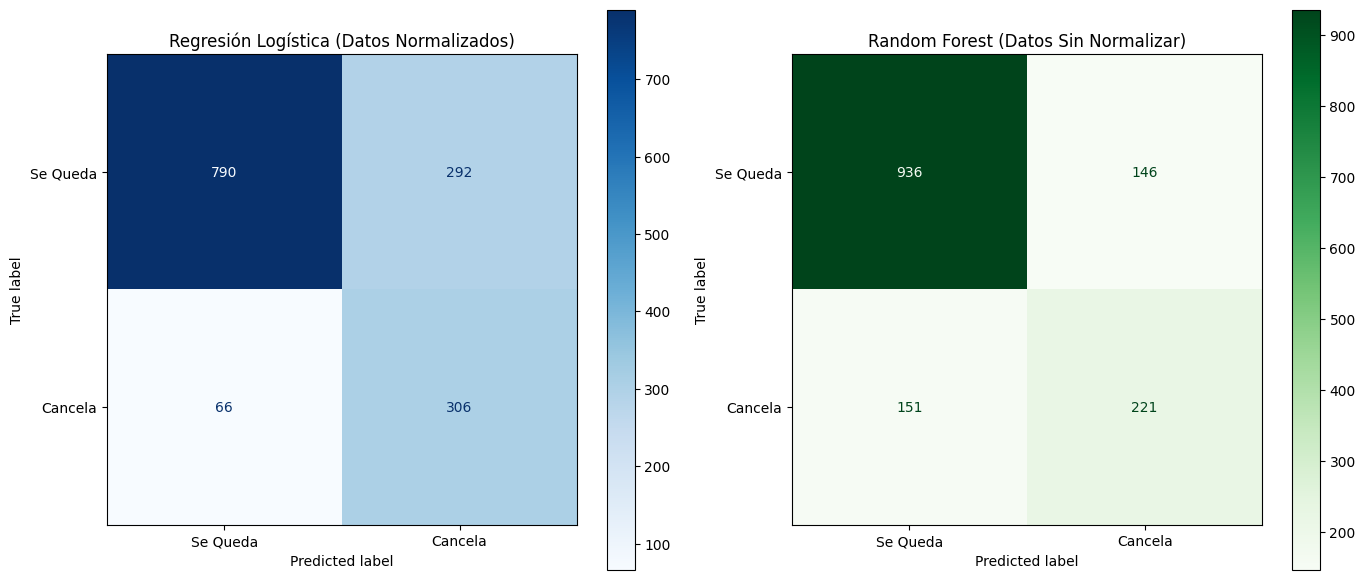

REGRESIÓN LOGÍSTICA (NORMALIZADO) - Métricas
              precision    recall  f1-score   support

           0       0.92      0.73      0.82      1082
           1       0.51      0.82      0.63       372

    accuracy                           0.75      1454
   macro avg       0.72      0.78      0.72      1454
weighted avg       0.82      0.75      0.77      1454

RANDOM FOREST (SIN NORMALIZAR) - Métricas
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      1082
           1       0.60      0.59      0.60       372

    accuracy                           0.80      1454
   macro avg       0.73      0.73      0.73      1454
weighted avg       0.79      0.80      0.80      1454



In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# 1. Preparar datos base
df = pd.read_csv("TelecomX_Clean.csv")
df = df.drop('customerID', axis=1)
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(df['account.Charges.Total'].median())
df['Churn'] = df['Churn'].astype(int)

# One-Hot Encoding
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns
if 'Churn' in categorical_cols:
    categorical_cols = categorical_cols.drop('Churn')
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 2. Separar datos (Train / Test) ANTES de balancear y normalizar (Best Practice)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Balancear SOLO los datos de entrenamiento (Train)
train_data = pd.concat([X_train, y_train], axis=1)
df_majority = train_data[train_data.Churn == 0]
df_minority = train_data[train_data.Churn == 1]

# Oversampling usando pandas
df_minority_upsampled = df_minority.sample(n=len(df_majority), replace=True, random_state=42)
train_balanced = pd.concat([df_majority, df_minority_upsampled])

X_train_bal = train_balanced.drop('Churn', axis=1)
y_train_bal = train_balanced['Churn']

# 4. PREPARAR DOS VERSIONES DE DATOS (Con y Sin Normalización)
numerical_cols = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']

# A. Sin Normalizar (Para Árboles)
X_train_unscaled = X_train_bal.copy()
X_test_unscaled = X_test.copy()

# B. Normalizado (Para Regresión Logística)
scaler = StandardScaler()
X_train_scaled = X_train_bal.copy()
X_test_scaled = X_test.copy()

# Normalizamos ajustando SOLO sobre el set de entrenamiento (evita trampa/fuga de datos)
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train_scaled[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test_scaled[numerical_cols])

# 5. ENTRENAMIENTO DE MODELOS
# Modelo 1: Regresión Logística (Necesita datos escalados)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train_bal)
lr_preds = lr_model.predict(X_test_scaled)

# Modelo 2: Random Forest (NO necesita datos escalados)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_unscaled, y_train_bal)
rf_preds = rf_model.predict(X_test_unscaled)

# 6. VISUALIZACIÓN DE MATRICES DE CONFUSIÓN
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay.from_predictions(y_test, lr_preds, ax=axes[0], cmap='Blues', 
                                        display_labels=['Se Queda', 'Cancela'])
axes[0].set_title('Regresión Logística (Datos Normalizados)')

ConfusionMatrixDisplay.from_predictions(y_test, rf_preds, ax=axes[1], cmap='Greens', 
                                        display_labels=['Se Queda', 'Cancela'])
axes[1].set_title('Random Forest (Datos Sin Normalizar)')

plt.tight_layout()
plt.show()

# 7. REPORTES DE CLASIFICACIÓN
print("="*50)
print("REGRESIÓN LOGÍSTICA (NORMALIZADO) - Métricas")
print("="*50)
print(classification_report(y_test, lr_preds))

print("="*50)
print("RANDOM FOREST (SIN NORMALIZAR) - Métricas")
print("="*50)
print(classification_report(y_test, rf_preds))

### 2.3 Evaluación de los Modelos

Aquí tienes un resumen directo y claro del análisis de los modelos:

**1. Random Forest (Overfitting)**

* **Problema:** Memorizó los datos. Tuvo una exactitud casi perfecta en entrenamiento (99.3%), pero cayó al 79.5% al probarlo con datos nuevos, perdiendo eficacia.
* **Solución:** Reducir su complejidad (ej. limitar la profundidad de los árboles o exigir más muestras para dividirse) o cambiar a un modelo más robusto como XGBoost.

**2. Regresión Logística (Ligero Underfitting)**

* **Problema/Ventaja:** Es muy estable (76.2% en entrenamiento vs 75.3% en prueba), lo que significa que generaliza excelente. Sin embargo, al ser un modelo simple, no alcanza exactitudes muy altas (Underfitting leve).
* **Solución:** Aumentar su complejidad matemática (agregando variables combinadas o polinomiales) o ajustar su nivel de regularización para que capte patrones más complejos.

### Interpretacion y Conclusiones

C:\Users\spide\AppData\Local\Temp\ipykernel_20404\3337362587.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lr_coefs, x='Coefficient', y='Feature', ax=axes[0], palette='coolwarm')
C:\Users\spide\AppData\Local\Temp\ipykernel_20404\3337362587.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_importances, x='Importance', y='Feature', ax=axes[1], palette='viridis')


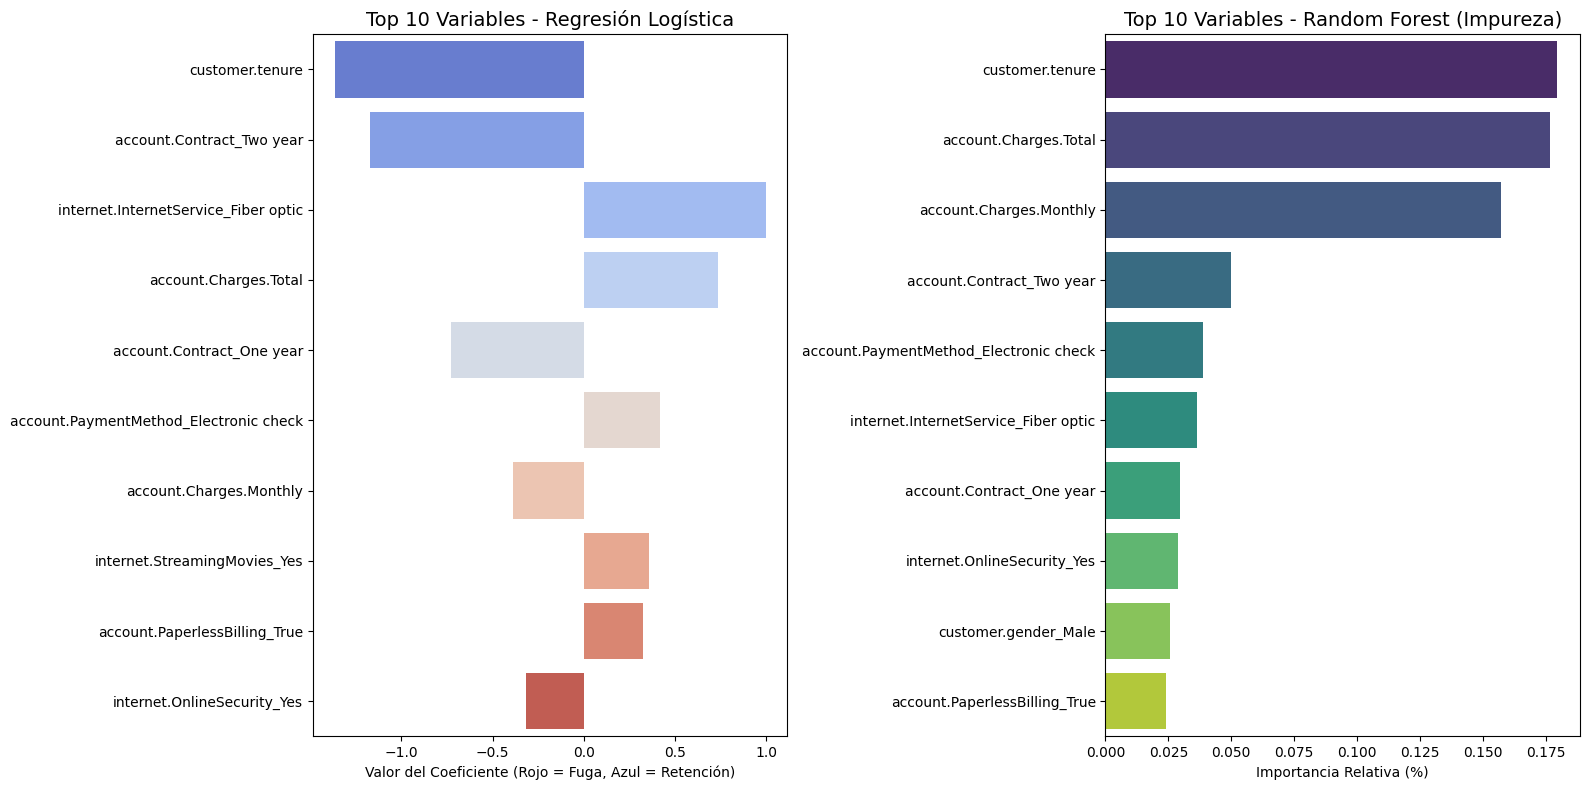

In [20]:
import seaborn as sns

# 1. Extraer Coeficientes de la Regresión Logística
lr_coefs = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': lr_model.coef_[0]
})
# Ordenar por valor absoluto para ver los más fuertes (sean positivos o negativos)
lr_coefs['Abs_Coefficient'] = lr_coefs['Coefficient'].abs()
lr_coefs = lr_coefs.sort_values(by='Abs_Coefficient', ascending=False).head(10)

# 2. Extraer Importancia del Random Forest (Gini Importance)
rf_importances = pd.DataFrame({
    'Feature': X_train_bal.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(10)

# 3. Crear Gráfico Comparativo
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Gráfico 1: Regresión Logística (Impacto Direccional)
sns.barplot(data=lr_coefs, x='Coefficient', y='Feature', ax=axes[0], palette='coolwarm')
axes[0].set_title('Top 10 Variables - Regresión Logística', fontsize=14)
axes[0].set_xlabel('Valor del Coeficiente (Rojo = Fuga, Azul = Retención)')
axes[0].set_ylabel('')

# Gráfico 2: Random Forest (Importancia de Separación)
sns.barplot(data=rf_importances, x='Importance', y='Feature', ax=axes[1], palette='viridis')
axes[1].set_title('Top 10 Variables - Random Forest (Impureza)', fontsize=14)
axes[1].set_xlabel('Importancia Relativa (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### Conclusiones

**1. El Modelo Ganador**
Tras preparar, balancear y evaluar los datos, la Regresión Logística (con datos normalizados) demostró ser el modelo más valioso para la empresa. Aunque el Random Forest tuvo una exactitud global ligeramente superior, sufrió de sobreajuste y dejó escapar a muchos clientes. La Regresión Logística, en cambio, logró un Recall del 82%, lo que garantiza que el negocio detectará a tiempo a la gran mayoría de los usuarios que están a punto de cancelar, permitiendo tomar medidas preventivas.

**2. ¿Quiénes cancelan?**
Gracias al análisis de correlación y la importancia de variables, identificamos que la fuga de clientes no es aleatoria. El usuario con mayor riesgo de abandono cumple con este perfil:
    -   Se encuentra en su primer año de servicio (la antigüedad baja es el mayor factor de riesgo).

    -   Tiene un contrato de renovación mensual ("Month-to-month").
    
    -   Utiliza el servicio de Internet por Fibra Óptica.
    
    -   Realiza sus pagos mediante cheque electrónico.